### What is Middleware in LangChain?
In LangChain, Middleware refers to code that runs before or after your main chain/LLM call. It acts like a layer that can:

* Log requests and responses
* Modify input/output
* Add monitoring / tracing
* Handle errors
* Add authentication
* Measure time (latency)
* Filter or transform data

In [ ]:
import os
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3-32b")


ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B138819400>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B138819E80>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### Summarization Middleware

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context, Summarization is useful for the following:

* Long-running conversation that exceed context window
* Multi-turn dialogues with extensive history. 
* Applications where preserving full conversation context matters

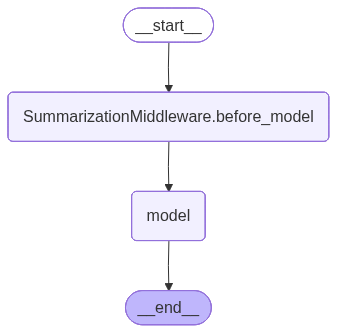

In [9]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

llm = "google_genai:gemini-2.5-flash"

memory = InMemorySaver()

agent = create_agent(
    model=llm,
    checkpointer=memory,
    middleware=[
        SummarizationMiddleware(
            model=llm,
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    ]
)
agent


In [10]:
config = {"configurable":{"thread_id":"test_id"}}

In [14]:
questions=[
    "what is the capital of India",
    "who is the president of India",
    "what comes after 10 in counting",
    "Who does mean  by Apple in Hindi",
    "Number of States in india",
    "First President of India after freedom"
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]}, config)
    print(f"messages: {response}")
    print(f"Messages: {len(response['messages'])}")

messages: {'messages': [HumanMessage(content='what is the capital of India', additional_kwargs={}, response_metadata={}, id='2b696ff2-8d66-4f7e-bea4-0c95deacf8ea'), AIMessage(content='The capital of India is **New Delhi**.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e8464-454b-7d62-b39c-8796f6fa03c8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 38, 'total_tokens': 45, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 29}})]}
Messages: 2
messages: {'messages': [HumanMessage(content='what is the capital of India', additional_kwargs={}, response_metadata={}, id='2b696ff2-8d66-4f7e-bea4-0c95deacf8ea'), AIMessage(content='The capital of India is **New Delhi**.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'mod

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 26.891306286s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-Fre